In [15]:
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [16]:
file_path = '../data/analysis/extended_analysis.csv'
output_dir = '../image/analysis/'
df = pd.read_csv(file_path)

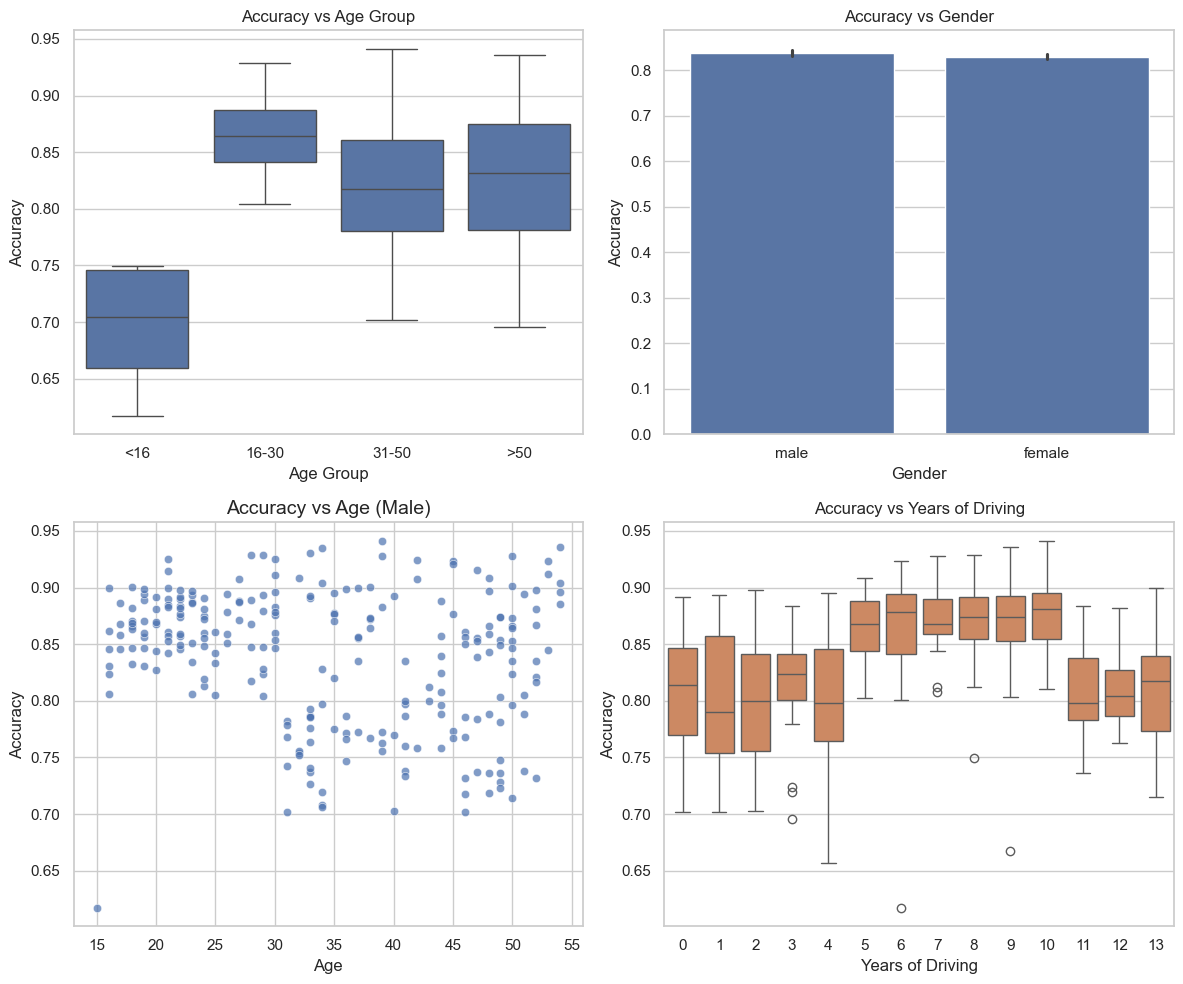

In [17]:
import os

# 重新创建 AgeGroup 列并确保它已正确添加到数据集中
age_bins = [0, 16, 30, 50, 100]
age_labels = ['<16', '16-30', '31-50', '>50']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# 创建一个 2x2 网格的图形，背景色设置为白色
fig, axes = plt.subplots(2, 2, figsize=(12, 10), facecolor='white')

# 1. 准确率与年龄段的关系
age_group_plot_path = os.path.join(output_dir, "Accuracy_vs_Age_Group.png")
sns.boxplot(x='AgeGroup', y='Accuracy', data=df, ax=axes[0, 0])
axes[0, 0].set_title("Accuracy vs Age Group")
axes[0, 0].set_xlabel("Age Group")
axes[0, 0].set_ylabel("Accuracy")
fig.savefig(age_group_plot_path)

# 2. 准确率与性别的关系
gender_plot_path = os.path.join(output_dir, "Accuracy_vs_Gender.png")
sns.barplot(x='Gender', y='Accuracy', data=df, ax=axes[0, 1])
axes[0, 1].set_title("Accuracy vs Gender")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Accuracy")
fig.savefig(gender_plot_path)

# 3. 年龄与性别与准确率的关系 (男性)
male_plot_path = os.path.join(output_dir, "Accuracy_vs_Age_Male.png")
df_male = df[df['Gender'] == 'male']
sns.scatterplot(x='Age', y='Accuracy', data=df_male, ax=axes[1, 0], alpha=0.7)
axes[1, 0].set_title("Accuracy vs Age (Male)", fontsize=14)
axes[1, 0].set_xlabel("Age", fontsize=12)
axes[1, 0].set_ylabel("Accuracy", fontsize=12)
fig.savefig(male_plot_path)

# 4. 年龄与性别与准确率的关系 (女性)
female_plot_path = os.path.join(output_dir, "Accuracy_vs_Age_Female.png")
df_female = df[df['Gender'] == 'female']
sns.scatterplot(x='Age', y='Accuracy', data=df_female, ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title("Accuracy vs Age (Female)", fontsize=14)
axes[1, 1].set_xlabel("Age", fontsize=12)
axes[1, 1].set_ylabel("Accuracy", fontsize=12)
fig.savefig(female_plot_path)

# 5. 准确率与驾龄的关系
years_of_driving_plot_path = os.path.join(output_dir, "Accuracy_vs_Years_of_Driving.png")
sns.boxplot(x='YearsOfDriving', y='Accuracy', data=df, ax=axes[1, 1])
axes[1, 1].set_title("Accuracy vs Years of Driving")
axes[1, 1].set_xlabel("Years of Driving")
axes[1, 1].set_ylabel("Accuracy")
fig.savefig(years_of_driving_plot_path)

# 调整布局后保存图表
plt.tight_layout()

plt.show()